<a href="https://colab.research.google.com/github/deniwidi/data-science-2026/blob/main/Pertemuan11_Deni_Widi_Alfian_240401010340.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Pertemuan ke-11

- Nama    : Deni Widi Alfian
- NIM     : 240401010340
- Kelas   : IF405

## Langkah 1: Generate & Eksplorasi Dataset
Buat dataset sintetis pelanggan dengan tiga kelompok tersembunyi, kemudian lakukan EDA
singkat.

Shape: (300, 4)
       pendapatan_tahunan  skor_belanja    usia
count              300.00        300.00  300.00
mean                69.80         53.23   42.07
std                 33.86         27.41   13.59
min                  9.04          0.12   18.00
25%                 32.86         27.00   30.00
50%                 70.63         55.09   43.00
75%                103.40         78.16   53.00
max                140.79        103.17   64.00


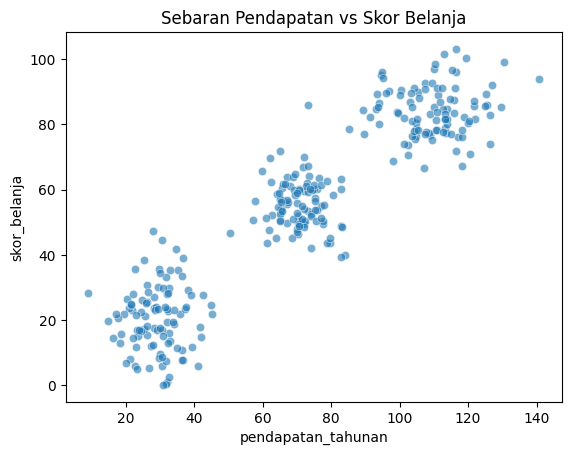

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Generate dataset sintetis pelanggan (3 kelompok tersembunyi)
np.random.seed(42)
grp1 = np.random.normal([30, 20], [8, 10], (100, 2))  # hemat
grp2 = np.random.normal([70, 55], [6, 8], (100, 2))   # menengah
grp3 = np.random.normal([110, 85], [10, 8], (100, 2)) # boros

data = np.vstack([grp1, grp2, grp3])
df = pd.DataFrame(data, columns=['pendapatan_tahunan', 'skor_belanja'])
df['usia'] = np.random.randint(18, 65, len(df))
df['gender'] = np.random.choice(['L', 'P'], len(df))

print('Shape:', df.shape)
print(df.describe().round(2))

sns.scatterplot(data=df, x='pendapatan_tahunan', y='skor_belanja', alpha=0.6)
plt.title('Sebaran Pendapatan vs Skor Belanja')
plt.show()

## Langkah 2: Preprocessing Data
Pilih fitur numerik yang relevan, kemudian terapkan `StandardScaler` agar setiap fitur memiliki
skala yang setara.

In [2]:
from sklearn.preprocessing import StandardScaler

X = df[['pendapatan_tahunan', 'skor_belanja']].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Rata-rata setelah scaling:', X_scaled.mean(axis=0).round(3))
print('Std setelah scaling:', X_scaled.std(axis=0).round(3))

Rata-rata setelah scaling: [-0.  0.]
Std setelah scaling: [1. 1.]


## Langkah 3: Metode Elbow untuk Menentukan K
Jalankan K-Means untuk K=1 hingga 10, simpan nilai WCSS setiap K, lalu plot grafik Elbow

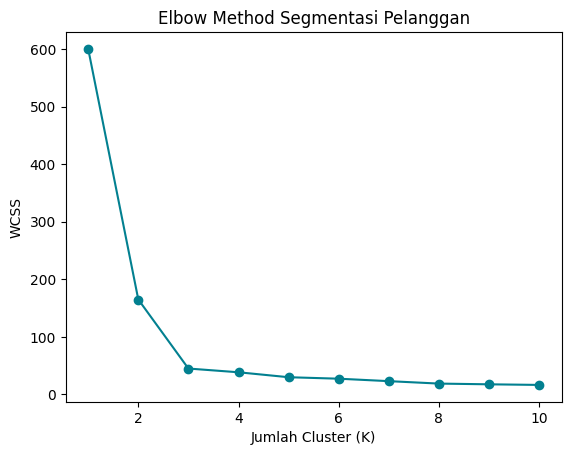

In [3]:
from sklearn.cluster import KMeans

wcss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, init='k-means++')
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.plot(range(1, 11), wcss, marker='o', color='#028090')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method Segmentasi Pelanggan')
plt.show()

Interpretasi Grafik Elbow:

Kurva mulai melandai secara tajam (membentuk siku/elbow) pada titik K = 3. Hasil ini sangat sesuai dengan jumlah kelompok yang diharapkan dari dataset sintetis yang telah kita buat di Langkah 1 (hemat, menengah, boros)

## Langkah 4: Melatih Model K-Means
Latih model K-Means dengan K optimal hasil pengamatan grafik Elbow, lalu tampilkan
koefisien evaluasinya.

In [4]:
from sklearn.metrics import silhouette_score

model = KMeans(n_clusters=3, random_state=42, init='k-means++')
model.fit(X_scaled)
df['cluster'] = model.labels_

print(f'WCSS akhir: {model.inertia_:.3f}')
print(f'Silhouette Score: {silhouette_score(X_scaled, model.labels_):.3f}')
print(df.groupby('cluster')[['pendapatan_tahunan', 'skor_belanja']].mean().round(2))

WCSS akhir: 44.919
Silhouette Score: 0.699
         pendapatan_tahunan  skor_belanja
cluster                                  
0                     70.75         55.04
1                     29.08         20.34
2                    109.19         84.01


## Langkah 5: Visualisasi Hasil Clustering
Buat scatter plot berwarna per cluster beserta posisi centroid, kemudian interpretasikan
karakteristik tiap segmen.
`centroids = scaler.inverse_trans`

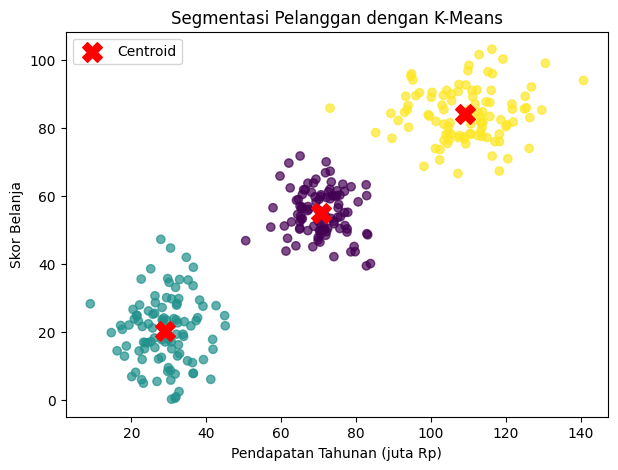

In [5]:
centroids = scaler.inverse_transform(model.cluster_centers_)

plt.figure(figsize=(7, 5))
plt.scatter(df['pendapatan_tahunan'], df['skor_belanja'],
            c=df['cluster'], cmap='viridis', alpha=0.7)

plt.scatter(centroids[:, 0], centroids[:, 1],
            c='red', marker='X', s=200, label='Centroid')

plt.xlabel('Pendapatan Tahunan (juta Rp)')
plt.ylabel('Skor Belanja')
plt.title('Segmentasi Pelanggan dengan K-Means')
plt.legend()
plt.show()

Interpretasi Tiap Cluster:  
- Cluster 0: Pendapatan rendah, skor belanja rendah = Segmen Hemat  
- Cluster 1: Pendapatan menengah, skor belanja menengah =Segmen Menengah
- Cluster 2: Pendapatan tinggi, skor belanja tinggi = Segmen Boros/Premium

## Langkah 6: Hierarchical Clustering (Pembanding)
Sebagai pembanding, bangun dendrogram menggunakan Ward linkage dan bandingkan
hasilnya dengan K-Means.

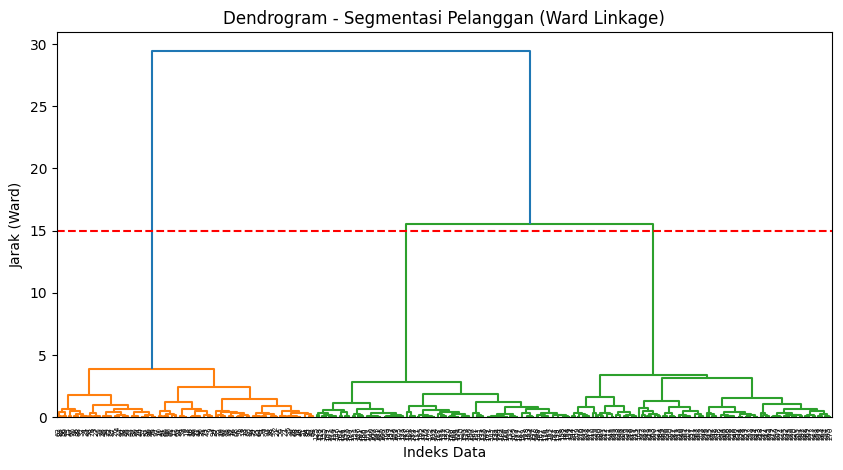

In [6]:
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title('Dendrogram - Segmentasi Pelanggan (Ward Linkage)')
plt.xlabel('Indeks Data')
plt.ylabel('Jarak (Ward)')
plt.axhline(y=15, color='red', linestyle='--') # contoh garis potong
plt.show()

Hasil perbandingan:

Garis potong merah pada jarak (ketinggian) y=15 memotong tepat 3 garis vertikal. Hal ini menunjukkan bahwa jumlah cluster dari dendrogram (3 cluster) sangat konsisten dengan hasil pencarian K optimal menggunakan Metode Elbow pada Langkah 3.